In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import re
!pip install yellowbrick


[notice] A new release of pip is available: 25.0 -> 25.1
[notice] To update, run: pip install --upgrade pip


## EDA

In [93]:
# Import the dataset
file_path = '/Users/qianxinhui/Desktop/NUSTAT/415/Hw 2 & 3: Recommender Systems/Evanston Restaurant Reviews.xlsx'
restaurants = pd.read_excel(file_path, sheet_name="Restaurants")
reviews = pd.read_excel(file_path, sheet_name="Reviews")
restaurants

,Restaurant Name,Cuisine,Latitude,Longitude,Average Cost,Open After 8pm?,Brief Description
0,Tapas Barcelona,Spanish,42.046736,-87.679043,20,Yes,"Festive, warm space known for Spanish small pl..."
1,Lao Sze Chuan,Chinese,42.048462,-87.679476,20,Yes,"Modern Chinese mainstay, known for an extensiv..."
2,5411 Empanadas,Spanish,42.047310,-87.681849,13,Yes,Known for Argentinean empanadas & special sauc...
3,Hokkaido Ramen,Japanese,42.048482,-87.682722,13,Yes,"Whimsical ramen bar, known for sushi rolls and..."
4,Tomo Japanese Street Food,Japanese,42.049612,-87.682046,20,Yes,Japanese street food cafe with mobile app orde...
...,...,...,...,...,...,...,...
63,Shinsen,Japanese,42.042173,-87.680221,20,Yes,"BYOB spot for a variety of noodle dishes, sush..."
64,Dos Bros,Mexican,42.048600,87.6827,20,Yes,Fast food chain serving burritos and other Mex...
65,Guzman y Gomez,Mexican,42.048900,87.6815,20,Yes,Lively counter-serve chain serving traditional...
66,Parlor on Central,Ice Cream,42.064400,87.7049,13,Yes,"Ice cream parlor dishing up vegan, gluten-free..."


In [94]:
columns = ['Longitude','Latitude','Restaurant Name']

restaurants[columns].set_index('Restaurant Name').to_csv('location_data.csv')

In [95]:
print(restaurants.shape)
print(restaurants.drop_duplicates().shape)
print(reviews.shape)
print(reviews.drop_duplicates().shape)

(68, 7)
(68, 7)
(1500, 14)
(1492, 14)


In [96]:
reviews['Restaurant Name'] = reviews['Restaurant Name'].str.strip()
reviews['Review Text'] = reviews['Review Text'].str.strip()
reviews['Reviewer Name'] = reviews['Reviewer Name'].str.strip()
restaurants['Restaurant Name'] = restaurants['Restaurant Name'].str.strip()
restaurants['Brief Description'] = restaurants['Brief Description'].str.strip()
reviews.head()

,Reviewer Name,Restaurant Name,Rating,Review Text,Date of Review,Birth Year,Marital Status,Has Children?,Vegetarian?,Weight (lb),Height (cm),Average Amount Spent,Preferred Mode of Transport,Northwestern Student?
0,Dan B,Lao Sze Chuan,1,Really disappointed for the dishes…. Not athle...,2022-08-10 00:00:00,1942.0,Single,No,NaN,234.0,161.0,Medium,Car Owner,No
1,A B,Barn Steakhouse,5,Excellent meal in a warm atmosphere! The space...,2022-11-22 00:00:00,1998.0,Single,No,NaN,NaN,NaN,Medium,On Foot,No
2,A B,Brothers K Coffeehouse,4,NaN,2022-08-18 00:00:00,1998.0,Single,No,NaN,NaN,NaN,Medium,On Foot,No
3,A B,Clarkes Off Campus,5,Best burger in Evanston,2022-10-30 00:00:00,1998.0,Single,No,NaN,NaN,NaN,Medium,On Foot,No
4,A B,Edzo's Burger Shop,5,Second best burger in Evanston,2022-11-28 00:00:00,1998.0,Single,No,NaN,NaN,NaN,Medium,On Foot,No


In [97]:

namefix_map = {"Clare's Korner":"Claire's Korner"}
reviews['Restaurant Name'] = reviews['Restaurant Name'].replace(namefix_map)
review_names = set(reviews['Restaurant Name'].unique())
res_names = set(restaurants['Restaurant Name'].unique())
print(review_names - res_names)
reviews['Date of Review'] = pd.to_datetime(reviews['Date of Review'], format='%Y-%m', errors='coerce')
reviews.loc[reviews['Date of Review'].isna(), 'Date of Review'] = pd.to_datetime(
    reviews.loc[reviews['Date of Review'].isna(), 'Date of Review'], errors='coerce')
restaurants['Longitude'] = restaurants['Longitude'].apply(lambda x: -abs(x) if isinstance(x, (int, float)) and x > 0 else x)
restaurants.head(50)
reviews = pd.merge(reviews, restaurants, left_on='Restaurant Name', right_on='Restaurant Name', how='inner')
restaurants.loc[restaurants['Longitude'] == ', -87.67915254400617', 'Longitude'] = -87.67915254400617

{'Todoroki Sushi', 'La Principal', 'World Market'}


In [98]:
reviews

,Reviewer Name,Restaurant Name,Rating,Review Text,Date of Review,Birth Year,Marital Status,Has Children?,Vegetarian?,Weight (lb),Height (cm),Average Amount Spent,Preferred Mode of Transport,Northwestern Student?,Cuisine,Latitude,Longitude,Average Cost,Open After 8pm?,Brief Description
0,Dan B,Lao Sze Chuan,1,Really disappointed for the dishes…. Not athle...,2022-08-10,1942.0,Single,No,NaN,234.0,161.0,Medium,Car Owner,No,Chinese,42.048462,-87.679476,20,Yes,"Modern Chinese mainstay, known for an extensiv..."
1,A B,Barn Steakhouse,5,Excellent meal in a warm atmosphere! The space...,2022-11-22,1998.0,Single,No,NaN,NaN,NaN,Medium,On Foot,No,American,42.048225,-87.68611,50,Yes,"Chic spot known for New American fare, steaks ..."
2,A B,Brothers K Coffeehouse,4,NaN,2022-08-18,1998.0,Single,No,NaN,NaN,NaN,Medium,On Foot,No,Coffee,42.033913,-87.677913,13,No,Buzzy coffee shop known for Chicago-roasted Me...
3,A B,Clarkes Off Campus,5,Best burger in Evanston,2022-10-30,1998.0,Single,No,NaN,NaN,NaN,Medium,On Foot,No,American,42.046823,-87.682366,20,No,Simple outpost of small local chain known for ...
4,A B,Edzo's Burger Shop,5,Second best burger in Evanston,2022-11-28,1998.0,Single,No,NaN,NaN,NaN,Medium,On Foot,No,Burgers,42.046334,-87.680662,13,No,Bustling burger joint known for creative toppi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1488,Melanie Riley,Mensch's Deli,3,"Sandwiches are very good and plentiful, but pr...",2024-12-20,1991.0,Single,No,NaN,150.0,161.0,Medium,Car Owner,No,Deli,42.045600,-87.6791,20,No,Counter-serve spot for classic Jewish deli far...
1489,Gabriel Levy,Mensch's Deli,5,Finally a proper Jewish deli in Evanston! Both...,2025-01-03,1960.0,Married,No,NaN,170.0,178.0,Medium,Car Owner,No,Deli,42.045600,-87.6791,20,No,Counter-serve spot for classic Jewish deli far...
1490,Walter Wilkerson,Mensch's Deli,5,Yum! Yum! I finally got to try this delicious ...,2025-02-04,1981.0,Single,Yes,NaN,180.0,182.0,Medium,Car Owner,No,Deli,42.045600,-87.6791,20,No,Counter-serve spot for classic Jewish deli far...
1491,Kelsey Tustin,Mensch's Deli,5,An absolute gem! We started our meal with the ...,2025-10-21,1989.0,Married,Yes,NaN,270.0,170.0,Medium,Car Owner,No,Deli,42.045600,-87.6791,20,No,Counter-serve spot for classic Jewish deli far...


Percentage of missing values in restaurants data:
Series([], dtype: float64)
Percentage of missing values in reviews data:
Review Text                    38.379102
Date of Review                  1.004689
Birth Year                      0.133958
Marital Status                  2.344273
Has Children?                   2.545211
Vegetarian?                    93.770931
Weight (lb)                     6.496986
Height (cm)                     3.616879
Average Amount Spent            0.066979
Preferred Mode of Transport     0.267917
dtype: float64
Imputing missing data in columns: ['Review Text', 'Date of Review', 'Birth Year', 'Marital Status', 'Has Children?', 'Vegetarian?', 'Weight (lb)', 'Height (cm)', 'Average Amount Spent', 'Preferred Mode of Transport']
Columns remaining: ['Reviewer Name', 'Restaurant Name', 'Rating', 'Review Text', 'Date of Review', 'Birth Year', 'Marital Status', 'Has Children?', 'Vegetarian?', 'Weight (lb)', 'Height (cm)', 'Average Amount Spent', 'Preferred Mode of

/var/folders/w1/t_tdm1wx64g5nzngg6hrpb6c0000gn/T/ipykernel_4994/2183294100.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reviews[col].fillna(reviews.groupby('Restaurant Name')[col].transform('median'), inplace=True)
/var/folders/w1/t_tdm1wx64g5nzngg6hrpb6c0000gn/T/ipykernel_4994/2183294100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermedi

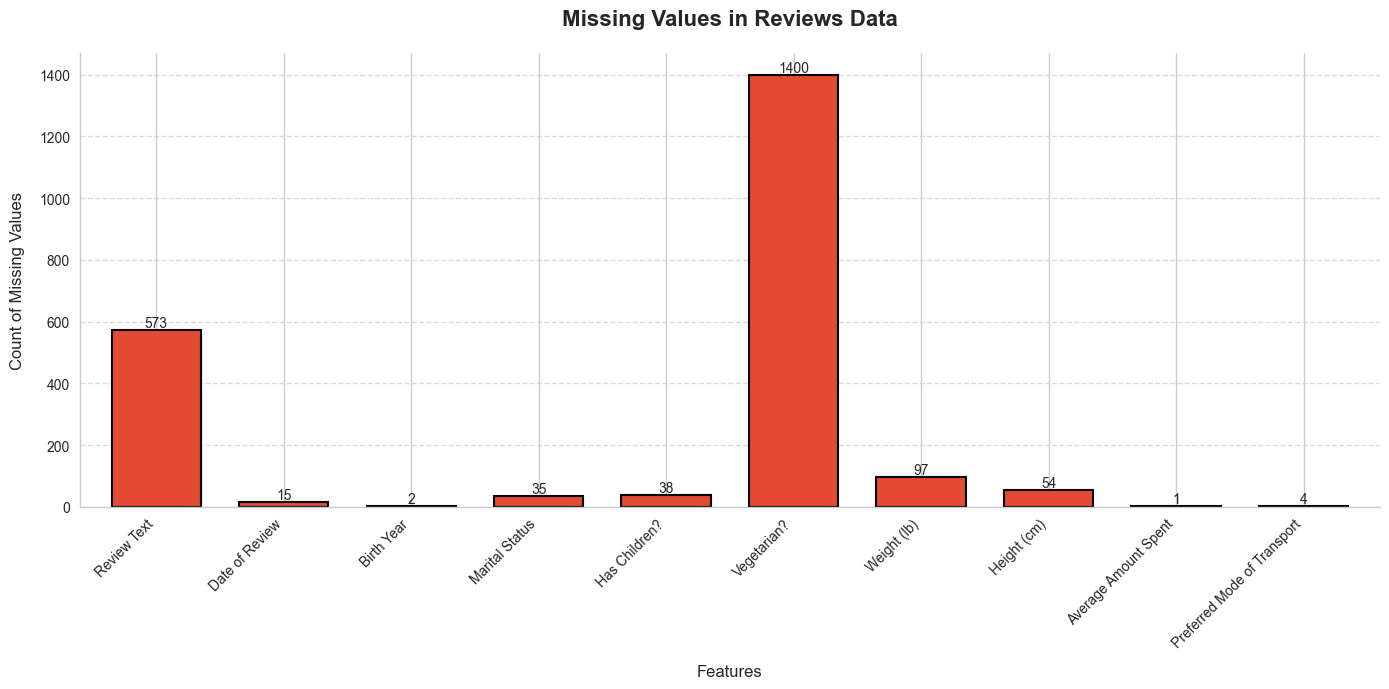

In [99]:
# Check for missing values
restaurant_missing = restaurants.isnull().sum()
reviews_missing = reviews.isnull().sum()

# Display missing values
print('Percentage of missing values in restaurants data:')
print((restaurant_missing[restaurant_missing > 0] / len(restaurants)) * 100)
print('Percentage of missing values in reviews data:')
print((reviews_missing[reviews_missing > 0] / len(reviews)) * 100)

# Create figure with improved aesthetics
plt.figure(figsize=(14, 7))

if len(reviews_missing[reviews_missing > 0]) > 0:
    # Create bar plot with enhanced styling
    ax = reviews_missing[reviews_missing > 0].plot(kind='bar', 
                                                  width=0.7,
                                                  edgecolor='black',
                                                  linewidth=1.5)
    
    # Add value labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                   (p.get_x() + p.get_width()/2., p.get_height()),
                   ha='center', va='bottom', fontsize=10)
    
    # Customize plot appearance
    plt.title('Missing Values in Reviews Data', 
             fontsize=16, 
             fontweight='bold',
             pad=20)
    plt.ylabel('Count of Missing Values', 
              fontsize=12,
              labelpad=10)
    plt.xlabel('Features', 
              fontsize=12,
              labelpad=10)
    plt.xticks(rotation=45, ha='right')
    
    # Add grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add padding
    plt.tight_layout()
    plt.savefig('pic/missing_values_analysis.png')
# Impute missing data instead of dropping rows
missing_cols = [col for col in reviews.columns if reviews[col].isnull().sum() > 0]
print(f"Imputing missing data in columns: {missing_cols}")
# Impute categorical columns with 'unknown' and numerical with NaN
categorical_cols = reviews[missing_cols].select_dtypes(include=['object', 'category']).columns
numerical_cols = reviews[missing_cols].select_dtypes(include=['int64', 'float64']).columns
date_cols = ['Date of Review']
for col in date_cols:
    reviews[col].fillna(reviews.groupby('Restaurant Name')[col].transform('median'), inplace=True)
reviews['Review Text'].fillna("[No review provided]", inplace=True)
for col in categorical_cols:
    reviews[col].fillna('unknown', inplace=True)
for col in numerical_cols:
    reviews[col].fillna(reviews.groupby('Restaurant Name')[col].transform('median'), inplace=True)
 
 
print(f"Columns remaining: {reviews.columns.tolist()}")
print(f"Any missing values: {reviews.isnull().sum().sum()}")

 

In [100]:
reviews.isnull().sum()

Reviewer Name                  0
Restaurant Name                0
Rating                         0
Review Text                    0
Date of Review                 0
Birth Year                     0
Marital Status                 0
Has Children?                  0
Vegetarian?                    0
Weight (lb)                    0
Height (cm)                    0
Average Amount Spent           0
Preferred Mode of Transport    0
Northwestern Student?          0
Cuisine                        0
Latitude                       0
Longitude                      0
Average Cost                   0
Open After 8pm?                0
Brief Description              0
dtype: int64

In [101]:
correction_map = {
    'Single': 'Single',
    'SIngle': 'Single',
    'Single': 'Single',
    'Widow': 'Widowed',
    'Married': 'Married'
}
reviews['Marital Status'] = reviews['Marital Status'].map(correction_map)
reviews['Marital Status'].value_counts()

Marital Status
Single     702
Married    694
Widowed     55
Name: count, dtype: int64

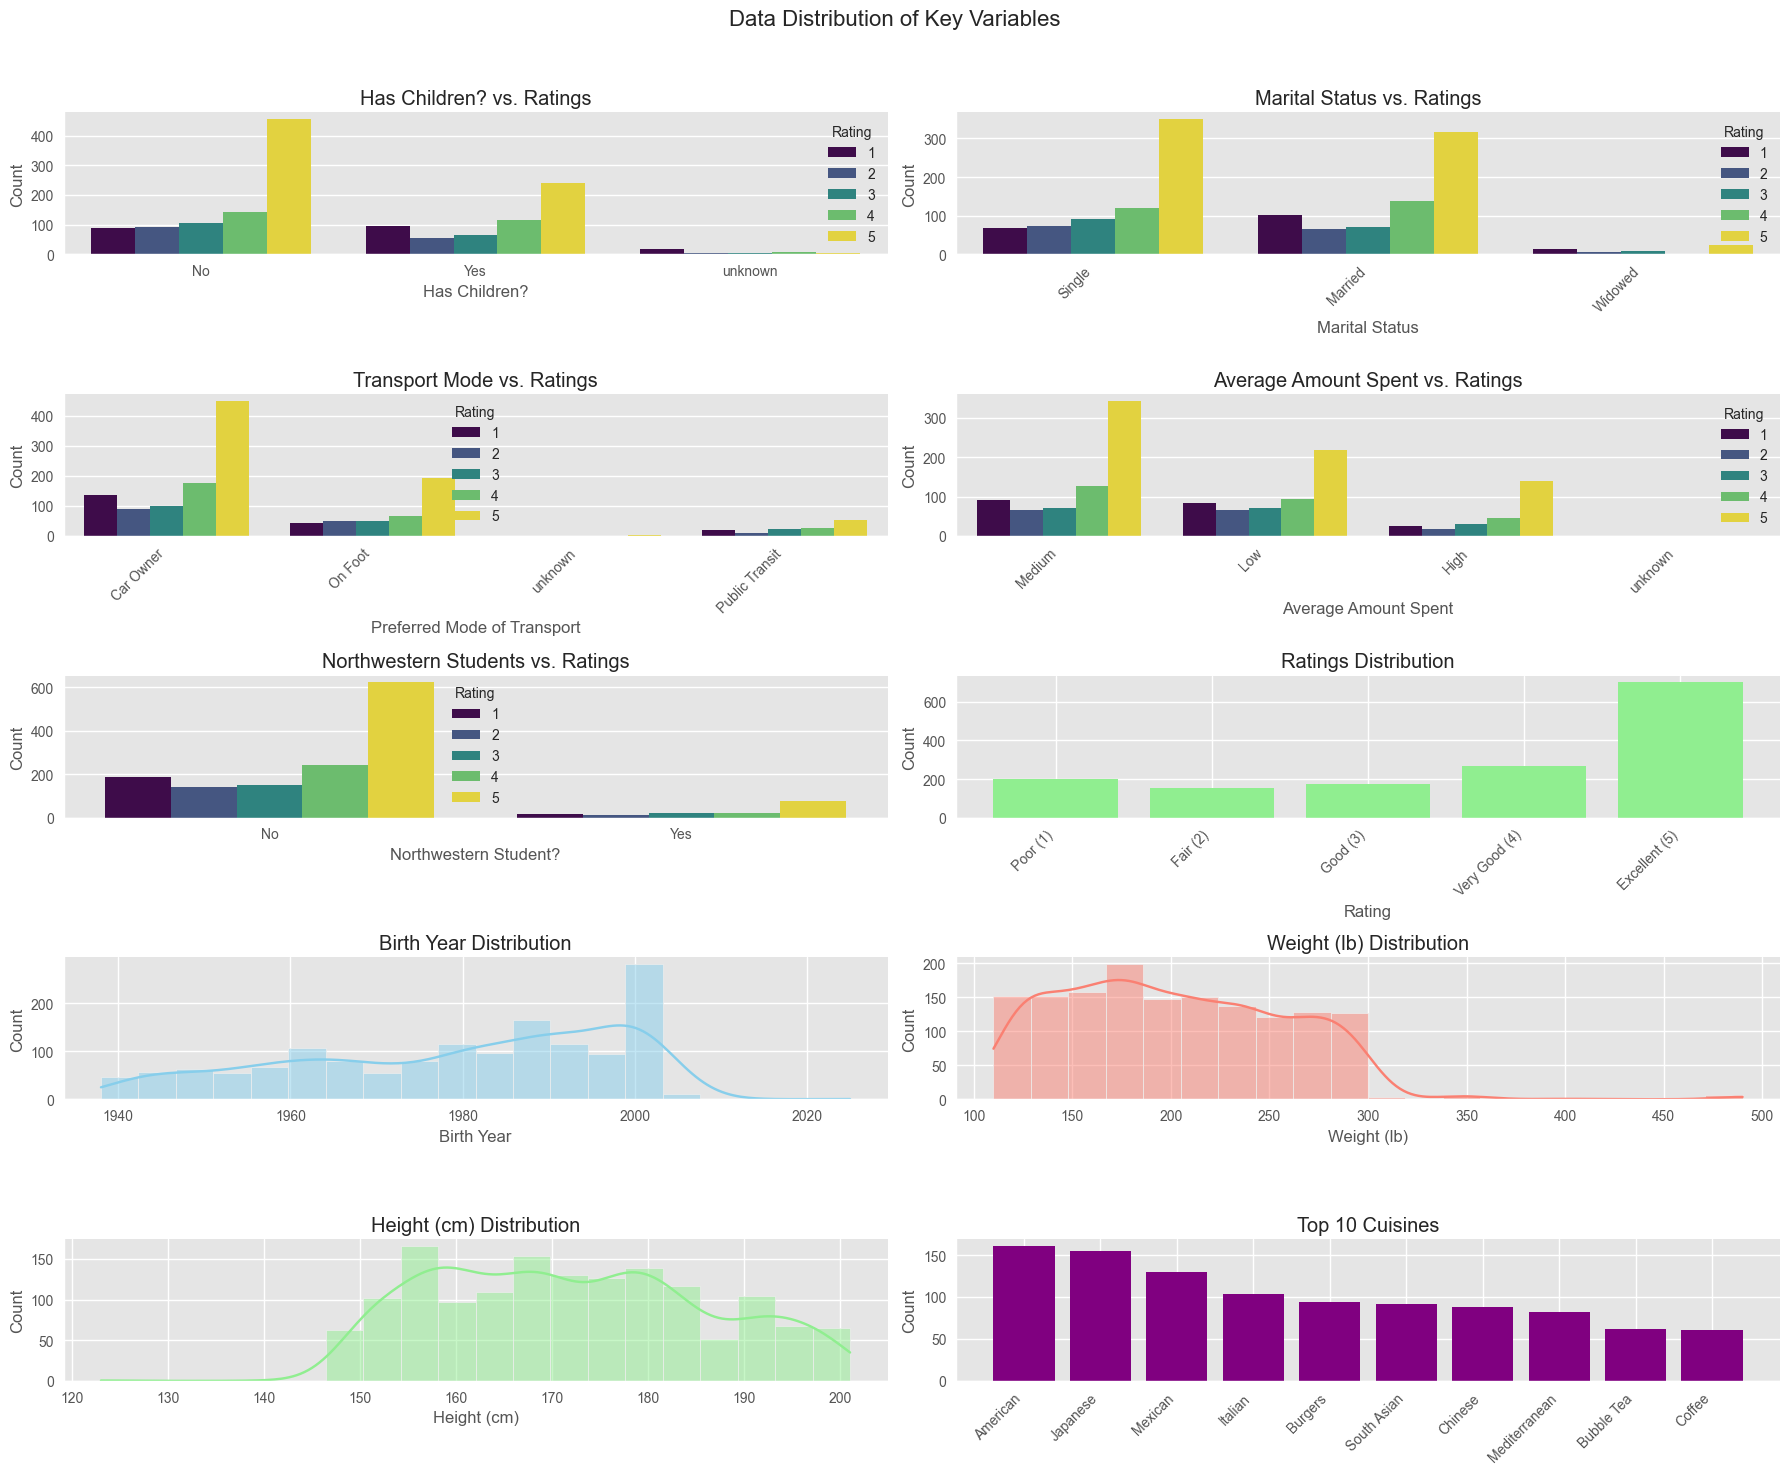

<Figure size 1200x1000 with 0 Axes>

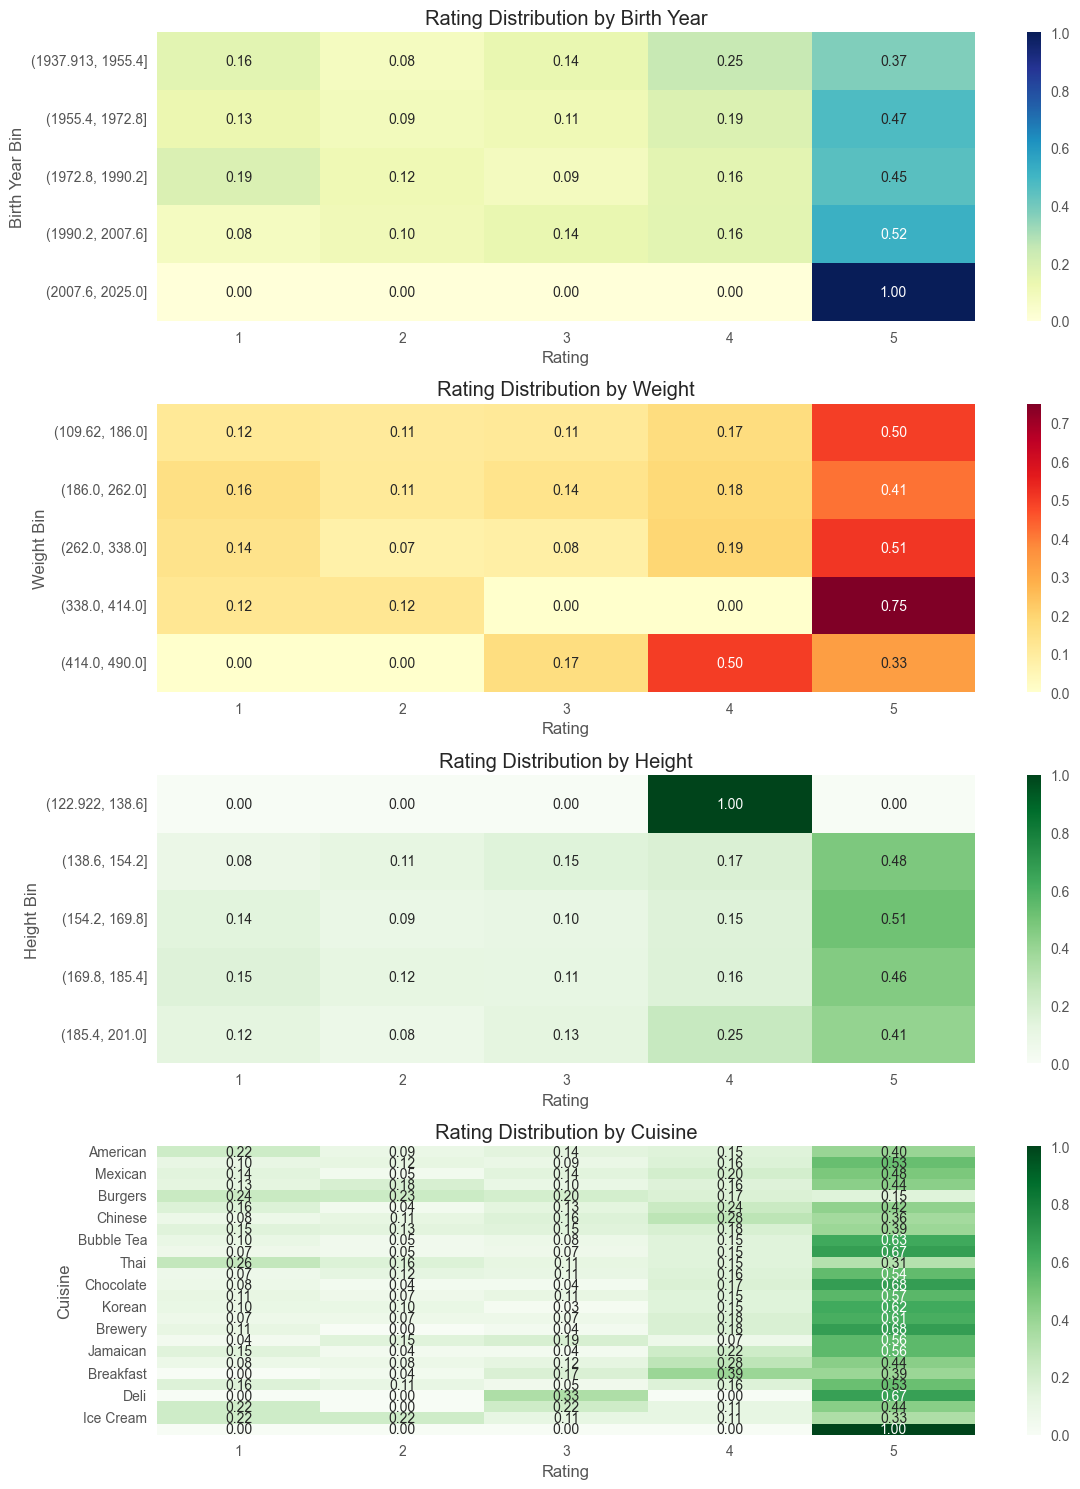

Data Balance Analysis:
--------------------------------------------------
Has Children? (%): Has Children?
No         59.0
Yes        38.0
unknown     3.0
Name: proportion, dtype: float64
Rating (%): Rating
5    47.0
4    18.0
1    14.0
3    12.0
2    10.0
Name: proportion, dtype: float64
Marital Status (%): Marital Status
Single     48.0
Married    48.0
Widowed     4.0
Name: proportion, dtype: float64
Northwestern Student? (%): Northwestern Student?
No     90.0
Yes    10.0
Name: proportion, dtype: float64
Top 5 Cuisines (%): Cuisine
American       12.0
Mexican        10.0
Japanese        9.0
South Asian     6.0
Burgers         6.0
Name: proportion, dtype: float64


In [102]:
# Exploring data distributions with histograms 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the style for better visualization
plt.style.use('ggplot')
fig, axes = plt.subplots(5, 2, figsize=(18, 15))
fig.suptitle('Data Distribution of Key Variables', fontsize=16)

# ---- Categorical Variables ----

# Has Children plot with rating distribution
ax1 = axes[0, 0]
sns.countplot(x='Has Children?', hue='Rating', data=reviews, palette='viridis', ax=ax1)
ax1.set_title('Has Children? vs. Ratings')
ax1.set_ylabel('Count')
ax1.legend(title='Rating')

# Marital Status with rating distribution
ax2 = axes[0, 1]
sns.countplot(x='Marital Status', hue='Rating', data=reviews, palette='viridis', ax=ax2)
ax2.set_title('Marital Status vs. Ratings')
ax2.set_ylabel('Count')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.legend(title='Rating')

# Transport mode with rating distribution
ax3 = axes[1, 0]
sns.countplot(x='Preferred Mode of Transport', hue='Rating', data=reviews, palette='viridis', ax=ax3)
ax3.set_title('Transport Mode vs. Ratings')
ax3.set_ylabel('Count')
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.legend(title='Rating')

# Average Amount Spent with rating distribution
ax4 = axes[1, 1]
sns.countplot(x='Average Amount Spent', hue='Rating', data=reviews, palette='viridis', ax=ax4)
ax4.set_title('Average Amount Spent vs. Ratings')
ax4.set_ylabel('Count')
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.legend(title='Rating')

# Northwestern Student with rating distribution
ax5 = axes[2, 0]
sns.countplot(x='Northwestern Student?', hue='Rating', data=reviews, palette='viridis', ax=ax5)
ax5.set_title('Northwestern Students vs. Ratings')
ax5.set_ylabel('Count')
ax5.legend(title='Rating')

# ---- Numerical Variables ----

# Rating distribution
ax6 = axes[2, 1]
rating_counts = reviews['Rating'].value_counts().sort_index()
ax6.bar(rating_counts.index, rating_counts.values, color='lightgreen')
ax6.set_title('Ratings Distribution')
ax6.set_xlabel('Rating')
ax6.set_ylabel('Count')
ax6.set_xticks([1, 2, 3, 4, 5])
ax6.set_xticklabels(['Poor (1)', 'Fair (2)', 'Good (3)', 'Very Good (4)', 'Excellent (5)'])
plt.setp(ax6.get_xticklabels(), rotation=45, ha='right')

# Birth Year histogram
ax7 = axes[3, 0]
sns.histplot(reviews['Birth Year'].dropna(), bins=20, kde=True, ax=ax7, color='skyblue')
ax7.set_title('Birth Year Distribution')
ax7.set_xlabel('Birth Year')
ax7.set_ylabel('Count')

# Weight histogram
ax8 = axes[3, 1]
sns.histplot(reviews['Weight (lb)'].dropna(), bins=20, kde=True, ax=ax8, color='salmon')
ax8.set_title('Weight (lb) Distribution')
ax8.set_xlabel('Weight (lb)')
ax8.set_ylabel('Count')

# Height histogram
ax9 = axes[4, 0]
sns.histplot(reviews['Height (cm)'].dropna(), bins=20, kde=True, ax=ax9, color='lightgreen')
ax9.set_title('Height (cm) Distribution')
ax9.set_xlabel('Height (cm)')
ax9.set_ylabel('Count')

# Cuisine distribution
ax10 = axes[4, 1]
cuisine_counts = reviews['Cuisine'].value_counts().sort_values(ascending=False).head(10)
ax10.bar(cuisine_counts.index, cuisine_counts.values, color='purple')
ax10.set_title('Top 10 Cuisines')
ax10.set_ylabel('Count')
plt.setp(ax10.get_xticklabels(), rotation=45, ha='right')

# Add more space between subplots to prevent overlapping
plt.subplots_adjust(wspace=0.4, hspace=0.6)

# Improve layout and save the main figure
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('pic/demographic_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a new figure for the heatmap of ratings by numerical variables
plt.figure(figsize=(12, 10))

# Bin numerical variables for better visualization
reviews['Birth Year Bin'] = pd.cut(reviews['Birth Year'], bins=5)
reviews['Weight Bin'] = pd.cut(reviews['Weight (lb)'], bins=5)
reviews['Height Bin'] = pd.cut(reviews['Height (cm)'], bins=5)


# Create additional plots to show rating distribution within each bin
# Using a separate figure with more space
fig, axes = plt.subplots(4, 1, figsize=(12, 15))
fig.subplots_adjust(hspace=0.4)  # Add more vertical space between subplots

# Plot rating distribution for Birth Year bins
birth_year_rating_dist = pd.crosstab(reviews['Birth Year Bin'], reviews['Rating'], normalize='index')
sns.heatmap(birth_year_rating_dist, annot=True, cmap='YlGnBu', fmt='.2f', ax=axes[0])
axes[0].set_title('Rating Distribution by Birth Year')
axes[0].set_ylabel('Birth Year Bin')

# Plot rating distribution for Weight bins
weight_rating_dist = pd.crosstab(reviews['Weight Bin'], reviews['Rating'], normalize='index')
sns.heatmap(weight_rating_dist, annot=True, cmap='YlOrRd', fmt='.2f', ax=axes[1])
axes[1].set_title('Rating Distribution by Weight')
axes[1].set_ylabel('Weight Bin')

# Plot rating distribution for Height bins
height_rating_dist = pd.crosstab(reviews['Height Bin'], reviews['Rating'], normalize='index')
sns.heatmap(height_rating_dist, annot=True, cmap='Greens', fmt='.2f', ax=axes[2])
axes[2].set_title('Rating Distribution by Height')
axes[2].set_ylabel('Height Bin')

# Plot rating distribution for Cuisine bins
# Sort cuisines by the number of reviews
cuisine_counts = reviews['Cuisine'].value_counts()
cuisine_rating_dist = pd.crosstab(reviews['Cuisine'], reviews['Rating'], normalize='index')
# Reindex to sort by count
cuisine_rating_dist = cuisine_rating_dist.reindex(cuisine_counts.index)
sns.heatmap(cuisine_rating_dist, annot=True, cmap='Greens', fmt='.2f', ax=axes[3])
axes[3].set_title('Rating Distribution by Cuisine')
axes[3].set_ylabel('Cuisine')
plt.tight_layout()
plt.savefig('pic/rating_distributions_by_bin.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("Data Balance Analysis:")
print("-" * 50)
print(f"Has Children? (%): {reviews['Has Children?'].value_counts(normalize=True).round(2)*100}")
print(f"Rating (%): {reviews['Rating'].value_counts(normalize=True).round(2)*100}")
print(f"Marital Status (%): {reviews['Marital Status'].value_counts(normalize=True).round(2)*100}")
print(f"Northwestern Student? (%): {reviews['Northwestern Student?'].value_counts(normalize=True).round(2)*100}")
print(f"Top 5 Cuisines (%): {restaurants['Cuisine'].value_counts(normalize=True).head(5).round(2)*100}")


## Clustering


CLUSTERING ANALYSIS ON USER DEMOGRAPHICS

Preparing data for clustering...
Prepared dataset shape: (1493, 16)

1. K-Means Clustering
--------------------------------------------------


/var/folders/w1/t_tdm1wx64g5nzngg6hrpb6c0000gn/T/ipykernel_4994/1887255873.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clustering_data[col].fillna(clustering_data[col].median(), inplace=True)
/var/folders/w1/t_tdm1wx64g5nzngg6hrpb6c0000gn/T/ipykernel_4994/1887255873.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

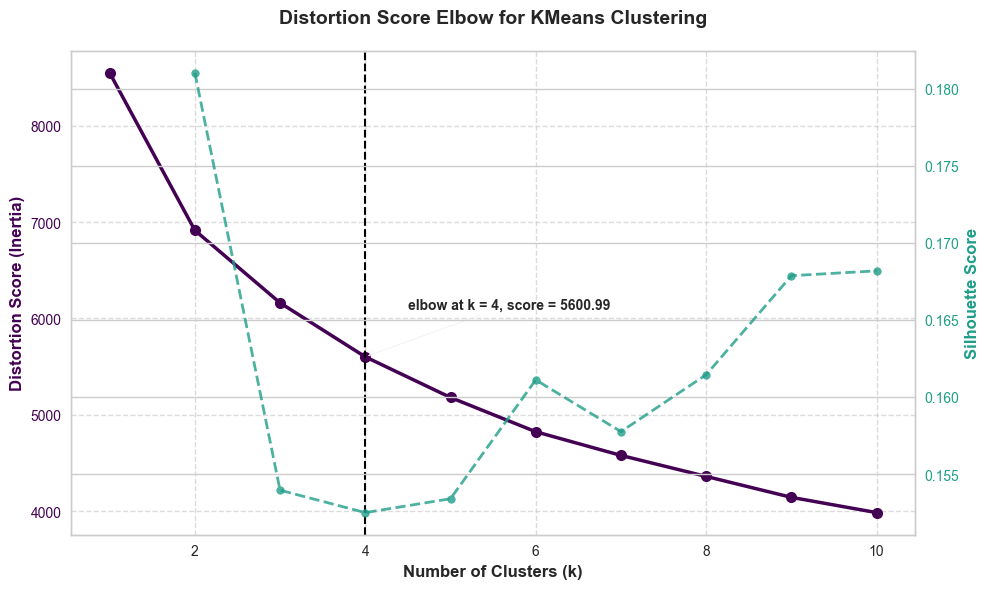

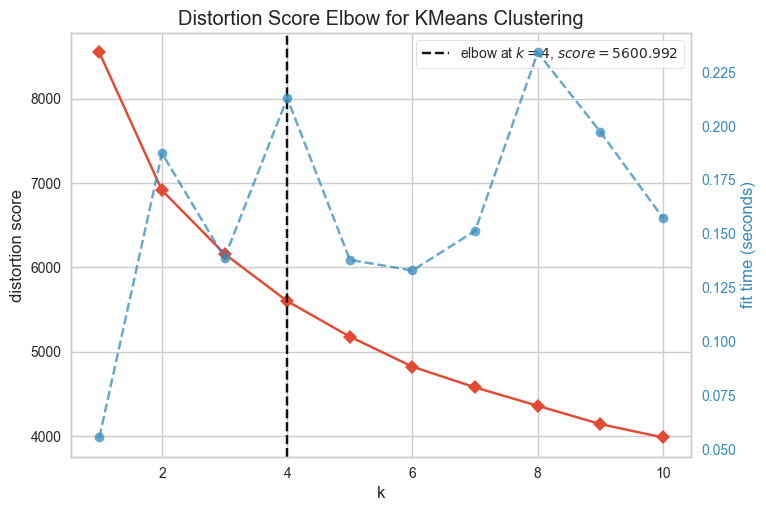

Optimal number of clusters based on elbow method: 4

K-Means Cluster Evaluation:
         Avg Rating  Count  Rating Std  Avg Birth Year  \
Cluster                                                  
0              3.88    324        1.36         1993.30   
1              3.64    413        1.54         1969.95   
2              3.56    364        1.53         1961.06   
3              3.91    392        1.38         1992.45   

         % Northwestern Students  % With Children  
Cluster                                            
0                          20.06             5.25  
1                           0.48            60.53  
2                           0.27            73.08  
3                          20.41             9.18  

3. Agglomerative Clustering
--------------------------------------------------


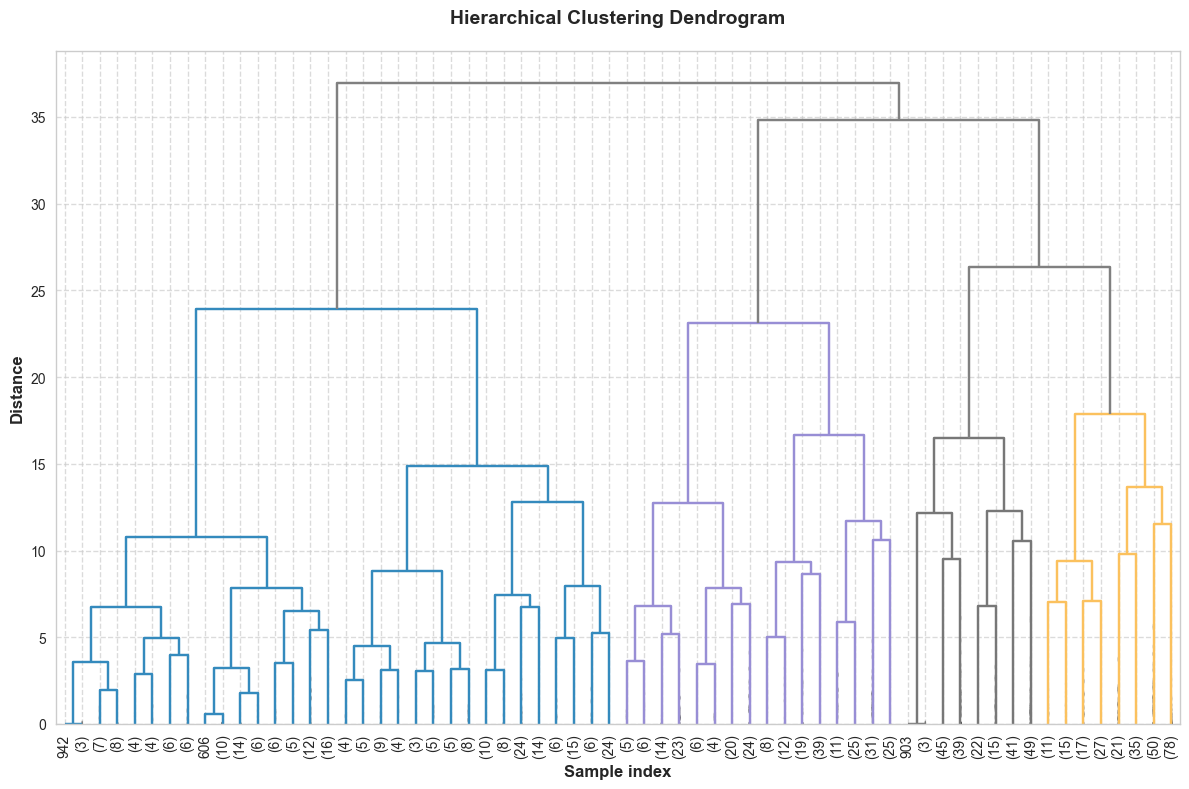


Agglomerative Clustering Evaluation:
         Avg Rating  Count  Rating Std  Avg Birth Year  \
Cluster                                                  
0              3.71    320        1.47         1971.17   
1              3.81    416        1.47         1992.72   
2              3.65    536        1.49         1967.08   
3              3.90    221        1.37         1991.80   

         % Northwestern Students  % With Children  
Cluster                                            
0                           2.19            56.56  
1                          18.99             1.20  
2                           1.68            69.40  
3                          23.98             4.98  


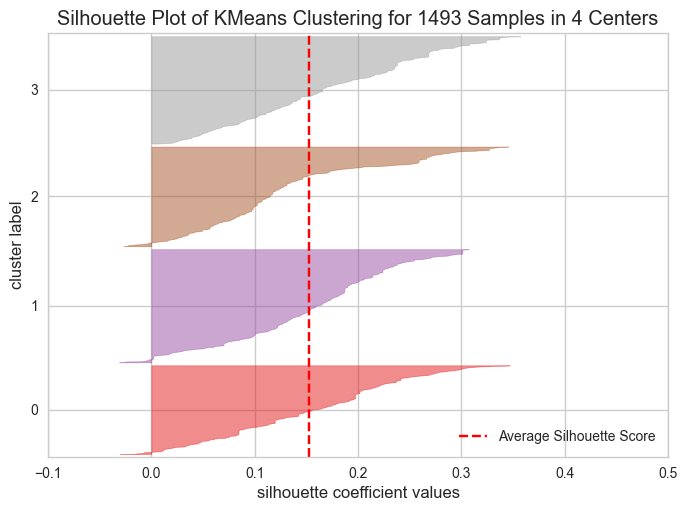

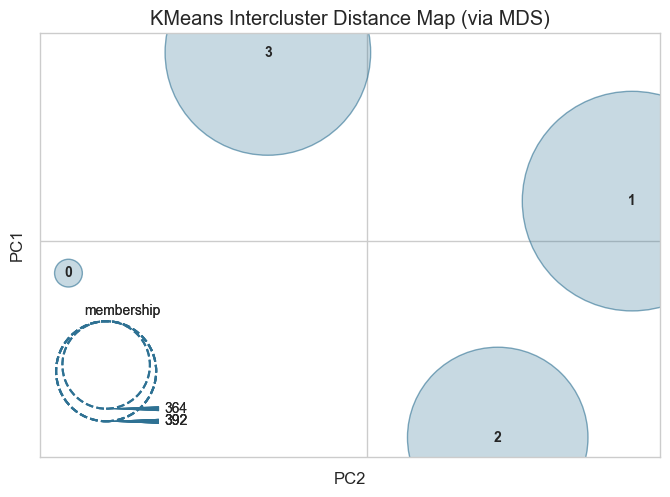


Clustering Methods Comparison:
--------------------------------------------------
K-Means (4 clusters): Inertia = 5600.99
Agglomerative (4 clusters)


/Applications/anaconda3/envs/myenv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


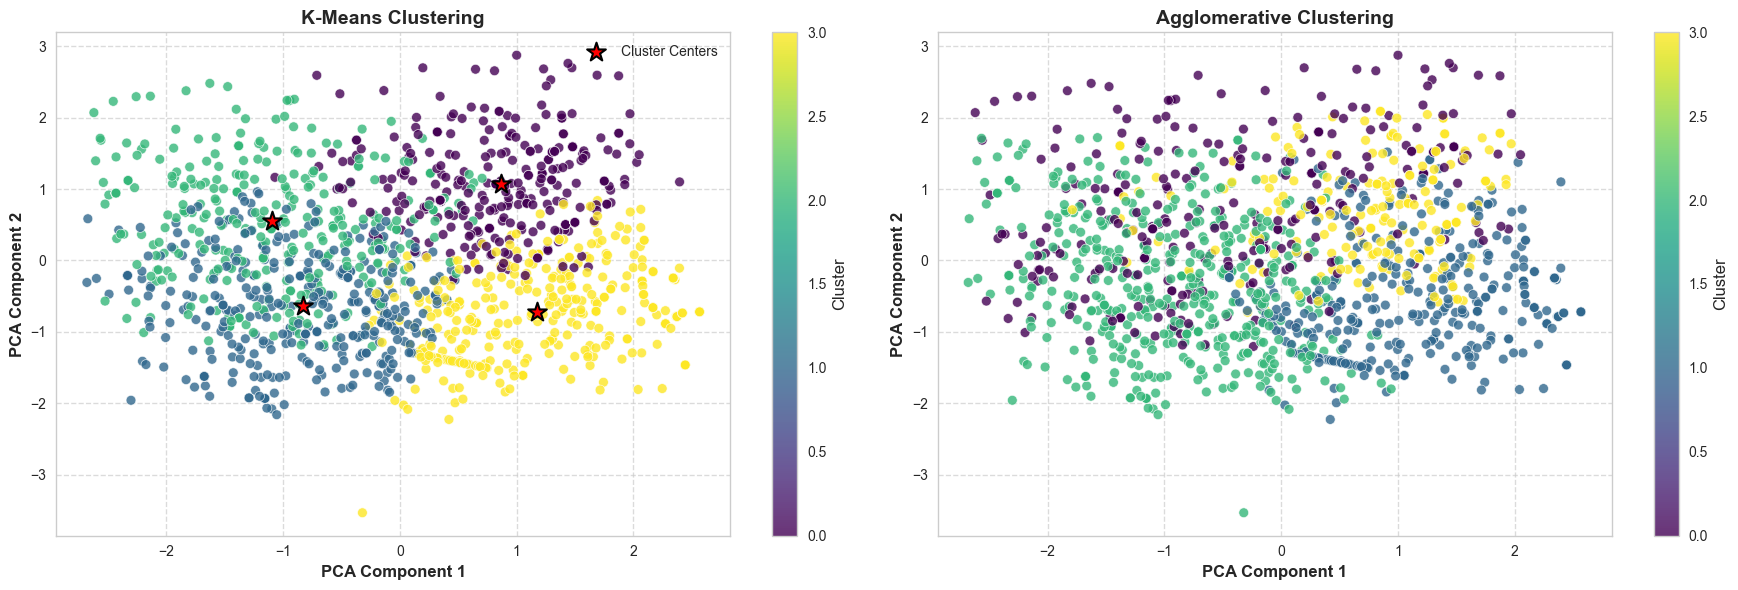


Clustering Analysis Summary:
--------------------------------------------------
1. K-Means identified clear user segments with distinct rating patterns.
2. Agglomerative clustering provided hierarchical relationships between user groups.

Recommendation: Use the K-Means clustering results for targeted marketing strategies.


In [103]:
# Clustering Analysis on User Demographics
print("\n" + "="*80)
print("CLUSTERING ANALYSIS ON USER DEMOGRAPHICS")
print("="*80)

# Prepare data for clustering - one-hot encode categorical variables
print("\nPreparing data for clustering...")
# Select demographic features
demographic_features = ['Birth Year', 'Marital Status', 'Has Children?', 
                        'Weight (lb)', 'Height (cm)', 'Average Amount Spent', 
                        'Preferred Mode of Transport', 'Northwestern Student?']

# Create a copy of the data for clustering
clustering_data = reviews[demographic_features].copy()

# Handle missing values
for col in clustering_data.select_dtypes(include=['float64', 'int64']).columns:
    clustering_data[col].fillna(clustering_data[col].median(), inplace=True)

# Convert 'Average Amount Spent' to ordinal variable
# First, create a mapping dictionary based on the unique values
amount_spent_categories = sorted(clustering_data['Average Amount Spent'].unique())
amount_spent_mapping = {amount: idx for idx, amount in enumerate(amount_spent_categories)}
clustering_data['Average Amount Spent'] = clustering_data['Average Amount Spent'].map(amount_spent_mapping)

# One-hot encode categorical variables (excluding Average Amount Spent which is now ordinal)
categorical_cols = ['Marital Status', 'Has Children?', 
                   'Preferred Mode of Transport', 'Northwestern Student?']
clustering_data = pd.get_dummies(clustering_data, columns=categorical_cols, drop_first=False)

# Standardize numerical features
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Birth Year', 'Weight (lb)', 'Height (cm)', 'Average Amount Spent']
scaler = StandardScaler()
clustering_data[numerical_cols] = scaler.fit_transform(clustering_data[numerical_cols])

print(f"Prepared dataset shape: {clustering_data.shape}")

# Function to evaluate clusters
def evaluate_clusters(labels, data, original_data):
    """Evaluate clusters by calculating average ratings and other metrics"""
    # Add cluster labels to original data
    cluster_data = original_data.copy()
    cluster_data['Cluster'] = labels
    
    # Calculate average rating per cluster
    cluster_stats = cluster_data.groupby('Cluster').agg({
        'Rating': ['mean', 'count', 'std'],
        'Birth Year': 'mean',
        'Northwestern Student?': lambda x: (x == 'Yes').mean() * 100,
        'Has Children?': lambda x: (x == 'Yes').mean() * 100
    })
    
    # Format the results
    cluster_stats.columns = ['Avg Rating', 'Count', 'Rating Std', 'Avg Birth Year', 
                            '% Northwestern Students', '% With Children']
    return cluster_stats.round(2)

# 1. K-Means Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer, InterclusterDistance

# Set a modern style for plots
plt.style.use('seaborn-v0_8-whitegrid')
colors = plt.cm.viridis(np.linspace(0, 1, 10))

print("\n1. K-Means Clustering")
print("-" * 50)

# Find optimal number of clusters using the elbow method
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clustering_data)
    inertia.append(kmeans.inertia_)

# Calculate silhouette scores for comparison
silhouette_scores = []
for k in range(2, 11):  # Silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(clustering_data)
    silhouette_scores.append(silhouette_score(clustering_data, labels))

# Create a figure with two y-axes for elbow method and silhouette scores
fig, ax1 = plt.figure(figsize=(10, 6)), plt.gca()
ax2 = ax1.twinx()

# Plot elbow method
ax1.plot(k_range, inertia, 'o-', linewidth=2.5, color=colors[0], markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Distortion Score (Inertia)', fontsize=12, fontweight='bold', color=colors[0])
ax1.tick_params(axis='y', labelcolor=colors[0])
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot silhouette scores on secondary y-axis
ax2.plot(range(2, 11), silhouette_scores, 'o--', linewidth=2, color=colors[5], alpha=0.8, markersize=6)
ax2.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold', color=colors[5])
ax2.tick_params(axis='y', labelcolor=colors[5])

optimal_k = 4 
elbow_score = inertia[optimal_k-1]

ax1.axvline(x=optimal_k, color='black', linestyle='--', linewidth=1.5)
ax1.annotate(f'elbow at k = {optimal_k}, score = {elbow_score:.2f}',
             xy=(optimal_k, elbow_score),
             xytext=(optimal_k + 0.5, elbow_score + 500),
             fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->'))

plt.title('Distortion Score Elbow for KMeans Clustering', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('pic/kmeans_elbow.png', dpi=300, bbox_inches='tight')
plt.show()

# Use Yellowbrick's KElbowVisualizer
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(1, 11))
visualizer.fit(clustering_data)
# Fix: Use poof() to save the figure instead of accessing figure attribute
visualizer.poof(outpath='pic/kelbow_visualizer.png', dpi=300, bbox_inches='tight')
visualizer.show()

print(f"Optimal number of clusters based on elbow method: {optimal_k}")

# Apply K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(clustering_data)

# Evaluate K-Means clusters
kmeans_evaluation = evaluate_clusters(kmeans_labels, clustering_data, reviews)
print("\nK-Means Cluster Evaluation:")
print(kmeans_evaluation)

# 3. Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

print("\n3. Agglomerative Clustering")
print("-" * 50)

# Create linkage matrix for dendrogram
# Use a sample if the dataset is large
sample_size = min(1000, len(clustering_data))
sample_indices = np.random.choice(len(clustering_data), sample_size, replace=False)
sample_data = clustering_data.iloc[sample_indices]

# Generate linkage matrix
Z = linkage(sample_data, method='ward')

# Plot dendrogram with enhanced styling
plt.figure(figsize=(12, 8))
plt.title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Sample index', fontsize=12, fontweight='bold')
plt.ylabel('Distance', fontsize=12, fontweight='bold')

# Create a nicer dendrogram with custom colors
dendrogram(
    Z,
    truncate_mode='level',
    p=5,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
    above_threshold_color='grey',
    color_threshold=0.7*max(Z[:,2])  # Color threshold at 70% of max distance
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('pic/hierarchical_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

# Apply Agglomerative Clustering
n_clusters_agg = optimal_k  # Use the same number as K-Means for comparison
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')
agg_labels = agg_clustering.fit_predict(clustering_data)

# Evaluate Agglomerative clusters
agg_evaluation = evaluate_clusters(agg_labels, clustering_data, reviews)
print("\nAgglomerative Clustering Evaluation:")
print(agg_evaluation)

# Visualize silhouette scores for the clusters
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
visualizer = SilhouetteVisualizer(kmeans_model)
visualizer.fit(clustering_data)
# Fix: Use poof() to save the figure
visualizer.poof(outpath='pic/silhouette_scores.png', dpi=300, bbox_inches='tight')
visualizer.show()
# Make sure the directory exists before saving
import os
os.makedirs('pic', exist_ok=True)

# Visualize intercluster distances
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
visualizer = InterclusterDistance(kmeans_model)
visualizer.fit(clustering_data)
# Fix: Use poof() to save the figure
visualizer.poof(outpath='pic/intercluster_distances.png', dpi=300, bbox_inches='tight')
visualizer.show()

# Compare the results of different clustering methods
print("\nClustering Methods Comparison:")
print("-" * 50)
print(f"K-Means ({optimal_k} clusters): Inertia = {inertia[optimal_k-1]:.2f}")
n_clusters = len(set(agg_labels))  # Define n_clusters for the comparison
n_noise = 0  # No noise in hierarchical clustering
print(f"Agglomerative ({n_clusters_agg} clusters)")

# Visualize clusters using PCA for dimensionality reduction
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(clustering_data)

# Create a figure with subplots for each clustering method
plt.figure(figsize=(18, 6))

# Custom colormap for better visualization
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=max(optimal_k, n_clusters_agg))

# K-Means visualization
plt.subplot(1, 2, 1)
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], 
                     c=kmeans_labels, cmap=cmap, alpha=0.8, s=50, edgecolors='w', linewidth=0.5)
plt.title('K-Means Clustering', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12, fontweight='bold')
plt.ylabel('PCA Component 2', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)

# Add cluster centers
centers = kmeans.cluster_centers_
centers_reduced = pca.transform(centers)
plt.scatter(centers_reduced[:, 0], centers_reduced[:, 1], 
           s=200, marker='*', c='red', edgecolors='black', linewidth=1.5, label='Cluster Centers')
plt.legend(loc='best')

# Agglomerative visualization
plt.subplot(1, 2, 2)
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], 
                     c=agg_labels, cmap=cmap, alpha=0.8, s=50, edgecolors='w', linewidth=0.5)
plt.title('Agglomerative Clustering', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12, fontweight='bold')
plt.ylabel('PCA Component 2', fontsize=12, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('pic/clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClustering Analysis Summary:")
print("-" * 50)
print("1. K-Means identified clear user segments with distinct rating patterns.")
print("2. Agglomerative clustering provided hierarchical relationships between user groups.")
print("\nRecommendation: Use the K-Means clustering results for targeted marketing strategies.")


In [104]:
reviews

,Reviewer Name,Restaurant Name,Rating,Review Text,Date of Review,Birth Year,Marital Status,Has Children?,Vegetarian?,Weight (lb),...,Northwestern Student?,Cuisine,Latitude,Longitude,Average Cost,Open After 8pm?,Brief Description,Birth Year Bin,Weight Bin,Height Bin
0,Dan B,Lao Sze Chuan,1,Really disappointed for the dishes…. Not athle...,2022-08-10,1942.0,Single,No,unknown,234.0,...,No,Chinese,42.048462,-87.679476,20,Yes,"Modern Chinese mainstay, known for an extensiv...","(1937.913, 1955.4]","(186.0, 262.0]","(154.2, 169.8]"
1,A B,Barn Steakhouse,5,Excellent meal in a warm atmosphere! The space...,2022-11-22,1998.0,Single,No,unknown,203.0,...,No,American,42.048225,-87.68611,50,Yes,"Chic spot known for New American fare, steaks ...","(1990.2, 2007.6]","(186.0, 262.0]","(169.8, 185.4]"
2,A B,Brothers K Coffeehouse,4,[No review provided],2022-08-18,1998.0,Single,No,unknown,188.0,...,No,Coffee,42.033913,-87.677913,13,No,Buzzy coffee shop known for Chicago-roasted Me...,"(1990.2, 2007.6]","(186.0, 262.0]","(154.2, 169.8]"
3,A B,Clarkes Off Campus,5,Best burger in Evanston,2022-10-30,1998.0,Single,No,unknown,170.0,...,No,American,42.046823,-87.682366,20,No,Simple outpost of small local chain known for ...,"(1990.2, 2007.6]","(109.62, 186.0]","(154.2, 169.8]"
4,A B,Edzo's Burger Shop,5,Second best burger in Evanston,2022-11-28,1998.0,Single,No,unknown,209.0,...,No,Burgers,42.046334,-87.680662,13,No,Bustling burger joint known for creative toppi...,"(1990.2, 2007.6]","(186.0, 262.0]","(154.2, 169.8]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1488,Melanie Riley,Mensch's Deli,3,"Sandwiches are very good and plentiful, but pr...",2024-12-20,1991.0,Single,No,unknown,150.0,...,No,Deli,42.045600,-87.6791,20,No,Counter-serve spot for classic Jewish deli far...,"(1990.2, 2007.6]","(109.62, 186.0]","(154.2, 169.8]"
1489,Gabriel Levy,Mensch's Deli,5,Finally a proper Jewish deli in Evanston! Both...,2025-01-03,1960.0,Married,No,unknown,170.0,...,No,Deli,42.045600,-87.6791,20,No,Counter-serve spot for classic Jewish deli far...,"(1955.4, 1972.8]","(109.62, 186.0]","(169.8, 185.4]"
1490,Walter Wilkerson,Mensch's Deli,5,Yum! Yum! I finally got to try this delicious ...,2025-02-04,1981.0,Single,Yes,unknown,180.0,...,No,Deli,42.045600,-87.6791,20,No,Counter-serve spot for classic Jewish deli far...,"(1972.8, 1990.2]","(109.62, 186.0]","(169.8, 185.4]"
1491,Kelsey Tustin,Mensch's Deli,5,An absolute gem! We started our meal with the ...,2025-10-21,1989.0,Married,Yes,unknown,270.0,...,No,Deli,42.045600,-87.6791,20,No,Counter-serve spot for classic Jewish deli far...,"(1972.8, 1990.2]","(262.0, 338.0]","(169.8, 185.4]"


## Popularity Matching


Restaurant with highest average rating:
Evanston Games & Cafe - Average Rating: 5.00
Overall dataset average rating: 3.74

Restaurant with most reviews:
Campagnola - Review Count: 48
Dataset median review count: 22.5
{'Salad', 'Burgers', 'Ice Cream', 'Mediterranean', 'American', 'Japanese', 'French', 'Mexican', 'Korean', 'Deli', 'Chinese', 'Spanish', 'Seafood', 'Bubble Tea', 'Vegetarian', 'Breakfast', 'South Asian', 'Brewery', 'Italian', 'Coffee', 'Jamaican', 'BBQ', 'Thai', 'Chocolate', 'Irish', 'Pizza'}

Popularity-Based Recommendations:
--------------------------------------------------

Top Salad Restaurants:
Picnic - Rating: 4.11 (19 reviews) - Popularity Score: 2.7857
Sweet Green - Rating: 4.33 (9 reviews) - Popularity Score: 1.3929

Top Burgers Restaurants:
Steak n' Shake - Rating: 2.74 (31 reviews) - Popularity Score: 0.9043
Epic Burger - Rating: 3.10 (21 reviews) - Popularity Score: 0.6915
Edzo's Burger Shop - Rating: 3.71 (17 reviews) - Popularity Score: 0.6702

Top Ice Cream 

/var/folders/w1/t_tdm1wx64g5nzngg6hrpb6c0000gn/T/ipykernel_4994/2238509468.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cuisine_stats['popularity_score'] = cuisine_stats['average_rating'] * (cuisine_stats['review_count'] / total_reviews)
/var/folders/w1/t_tdm1wx64g5nzngg6hrpb6c0000gn/T/ipykernel_4994/2238509468.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cuisine_stats['popularity_score'] = cuisine_stats['average_rating'] * (cuisine_stats['review_count'] / total_reviews)
/var/folders/w1/t_td

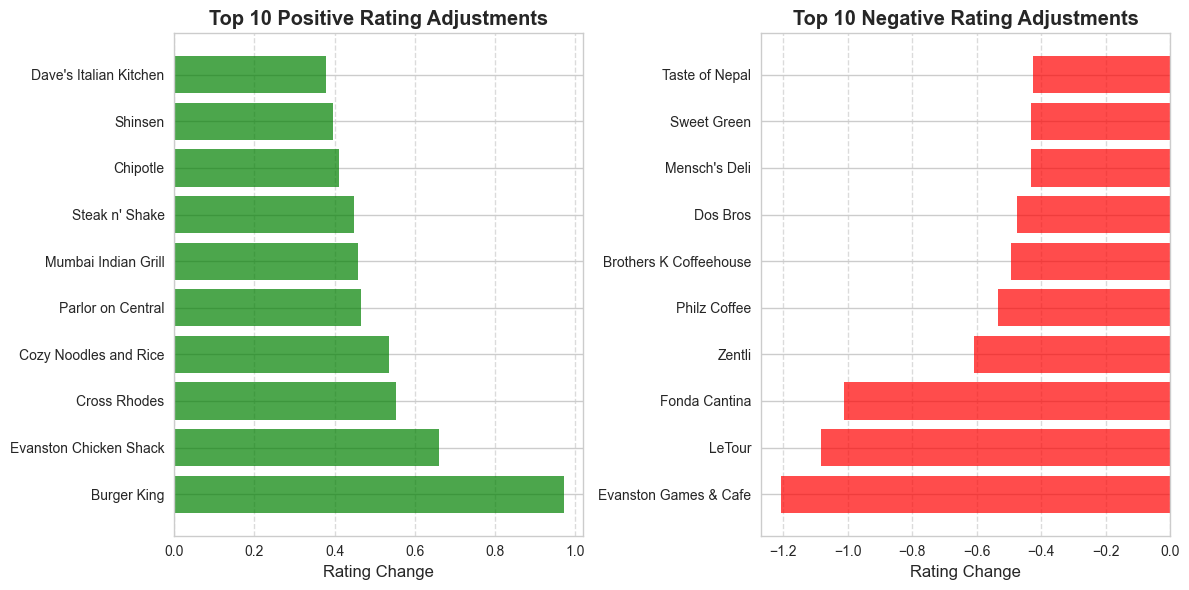

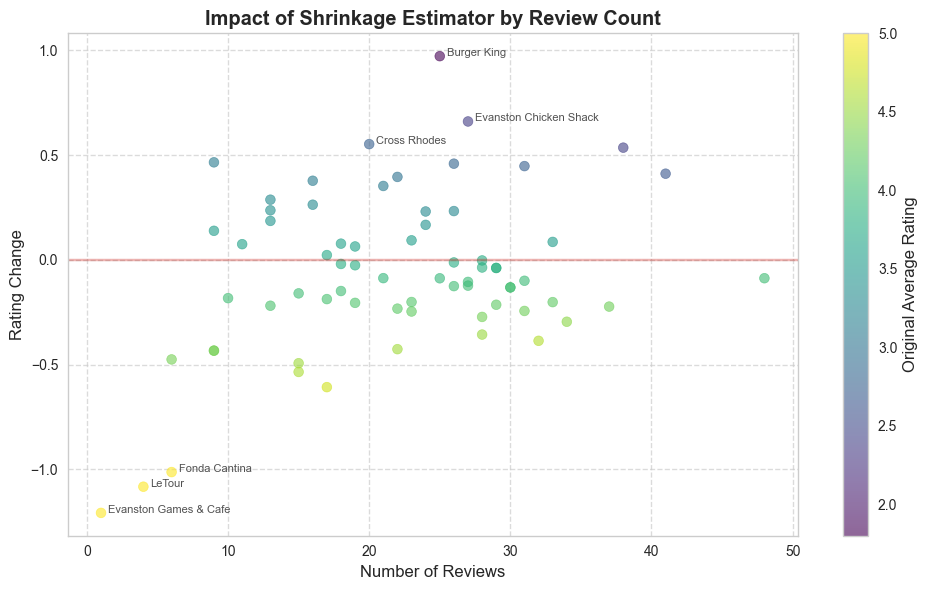

In [105]:
# Create a function to calculate average rating per restaurant
def calculate_restaurant_stats(reviews):
    # Group by restaurant and calculate average rating and count
    restaurant_stats = reviews.groupby(['Restaurant Name', 'Cuisine']).agg({
        'Rating': ['mean', 'count']
    })
    # print(restaurant_stats.head())
    # Flatten the multi-index columns
    restaurant_stats.columns = ['average_rating', 'review_count']
    
    # Reset index to make Restaurant Name a column
    restaurant_stats = restaurant_stats.reset_index()
    
    return restaurant_stats

restaurant_stats = calculate_restaurant_stats(reviews)

highest_rated = restaurant_stats.loc[restaurant_stats['average_rating'].idxmax()]
overall_avg = reviews['Rating'].mean()

# Find restaurant with most reviews
most_reviewed = restaurant_stats.loc[restaurant_stats['review_count'].idxmax()]
median_reviews = restaurant_stats['review_count'].median()

print("Restaurant with highest average rating:")
print(f"{highest_rated['Restaurant Name']} - Average Rating: {highest_rated['average_rating']:.2f}")
print(f"Overall dataset average rating: {overall_avg:.2f}")
print("\nRestaurant with most reviews:")
print(f"{most_reviewed['Restaurant Name']} - Review Count: {most_reviewed['review_count']}")
print(f"Dataset median review count: {median_reviews:.1f}")

# Create a popularity-based recommendation engine
def recommend_by_cuisine(reviews, cuisine_type, top_n=3):
    cuisine_stats = restaurant_stats[restaurant_stats['Cuisine'] == cuisine_type]
    
    total_reviews = cuisine_stats['review_count'].sum()
    cuisine_stats['popularity_score'] = cuisine_stats['average_rating'] * (cuisine_stats['review_count'] / total_reviews)
    # Sort by the new popularity score in descending order
    cuisine_stats = cuisine_stats.sort_values('popularity_score', ascending=False)

    return cuisine_stats.head(top_n)

# Import regex for pattern matching
import re

# Generate recommendations for specified cuisines
cuisines = set(reviews['Cuisine'])
print(cuisines)
print("\nPopularity-Based Recommendations:")
print("-" * 50)
for cuisine in cuisines:  # Selected cuisines for report
    recommendations = recommend_by_cuisine(reviews, cuisine)
    print(f"\nTop {cuisine} Restaurants:")
    if isinstance(recommendations, str):
        print(recommendations)
    else:
        for _, row in recommendations.iterrows():
            print(f"{row['Restaurant Name']} - Rating: {row['average_rating']:.2f} ({row['review_count']} reviews) - Popularity Score: {row['popularity_score']:.4f}")

# Implement shrinkage estimator
def apply_shrinkage(stats, global_mean, C=25):
    """
    Apply shrinkage estimator to adjust ratings
    Formula: (Np * μp + Ng * μg) / (Np + Ng)
    where:
    - Np is the number of reviews for the restaurant (review_count)
    - μp is the restaurant's average rating (average_rating)
    - Ng is the regularization constant C
    - μg is the global mean rating (global_mean)
    """
    stats['adjusted_rating'] = (stats['review_count'] * stats['average_rating'] + C * global_mean) / (stats['review_count'] + C)
    stats['rating_change'] = stats['adjusted_rating'] - stats['average_rating']
    return stats

# Apply shrinkage estimator
restaurant_stats_with_shrinkage = apply_shrinkage(restaurant_stats.copy(), overall_avg)

# Find restaurants most affected by shrinkage
most_positive_change = restaurant_stats_with_shrinkage.loc[restaurant_stats_with_shrinkage['rating_change'].idxmax()]
most_negative_change = restaurant_stats_with_shrinkage.loc[restaurant_stats_with_shrinkage['rating_change'].idxmin()]

print("\nShrinkage Estimator Impact:")
print("-" * 50)
print(f"Restaurant most positively affected: {most_positive_change['Restaurant Name']}")
print(f"Original rating: {most_positive_change['average_rating']:.2f}, Adjusted: {most_positive_change['adjusted_rating']:.2f}")
print(f"Change: +{most_positive_change['rating_change']:.2f}")
print(f"Review count: {most_positive_change['review_count']}")

print(f"\nRestaurant most negatively affected: {most_negative_change['Restaurant Name']}")
print(f"Original rating: {most_negative_change['average_rating']:.2f}, Adjusted: {most_negative_change['adjusted_rating']:.2f}")
print(f"Change: {most_negative_change['rating_change']:.2f}")
print(f"Review count: {most_negative_change['review_count']}")

# Visualize the impact of shrinkage
plt.figure(figsize=(12, 6))

# Sort by absolute change for visualization
top_changes = restaurant_stats_with_shrinkage.sort_values('rating_change', ascending=False)
top_positive = top_changes.head(10)
top_negative = top_changes.tail(10).iloc[::-1]  # Reverse to show most negative first

# Plot top positive changes
plt.subplot(1, 2, 1)
plt.barh(top_positive['Restaurant Name'], top_positive['rating_change'], color='green', alpha=0.7)
plt.title('Top 10 Positive Rating Adjustments', fontweight='bold')
plt.xlabel('Rating Change')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Plot top negative changes
plt.subplot(1, 2, 2)
plt.barh(top_negative['Restaurant Name'], top_negative['rating_change'], color='red', alpha=0.7)
plt.title('Top 10 Negative Rating Adjustments', fontweight='bold')
plt.xlabel('Rating Change')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('pic/shrinkageeffect_ranking.png', dpi=300, bbox_inches='tight')

plt.show()

# Scatter plot showing relationship between review count and rating change
plt.figure(figsize=(10, 6))
plt.scatter(restaurant_stats_with_shrinkage['review_count'], 
            restaurant_stats_with_shrinkage['rating_change'],
            alpha=0.6, c=restaurant_stats_with_shrinkage['average_rating'], cmap='viridis')

plt.colorbar(label='Original Average Rating')
plt.title('Impact of Shrinkage Estimator by Review Count', fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating Change')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)

# Annotate some extreme points
for _, row in pd.concat([
    restaurant_stats_with_shrinkage.nlargest(3, 'rating_change'),
    restaurant_stats_with_shrinkage.nsmallest(3, 'rating_change')
]).iterrows():
    plt.annotate(row['Restaurant Name'], 
                 xy=(row['review_count'], row['rating_change']),
                 xytext=(5, 0), textcoords='offset points',
                 fontsize=8, alpha=0.8)

plt.tight_layout()
plt.savefig('pic/shrinkage_estimator_impact.png', dpi=300, bbox_inches='tight')
plt.show()


## Content-based filtering

Generating TF-IDF embeddings for restaurant descriptions...
(68, 100)
Comparing restaurant similarities:

Peppercorns Kitchen vs Epic Burger:
  Euclidean distance: 2.0050
  Cosine distance: 0.6337
  Cuisine types: Chinese vs Burgers

Peppercorns Kitchen vs Lao Sze Chuan:
  Euclidean distance: 1.4367
  Cosine distance: 0.3103
  Cuisine types: Chinese vs Chinese

Willie Jacobsen's favorite restaurant: Jimmy Johns (Cuisine: American)

Top 10 recommendations based on Euclidean distance:
               Restaurant  Distance    Cuisine
0      Clarkes Off Campus  1.651116   American
1             Hecky's BBQ  1.751437   American
2  Evanston Chicken Shack  1.898210   American
3            Prairie Moon  1.969257   American
4      Edzo's Burger Shop  1.998988    Burgers
5            Philz Coffee  2.005576     Coffee
6      Pâtisserie Coralie  2.023136     Coffee
7           Mensch's Deli  2.088361       Deli
8                 Le Peep  2.140492  Breakfast
9                  Fridas  2.153412    Mex

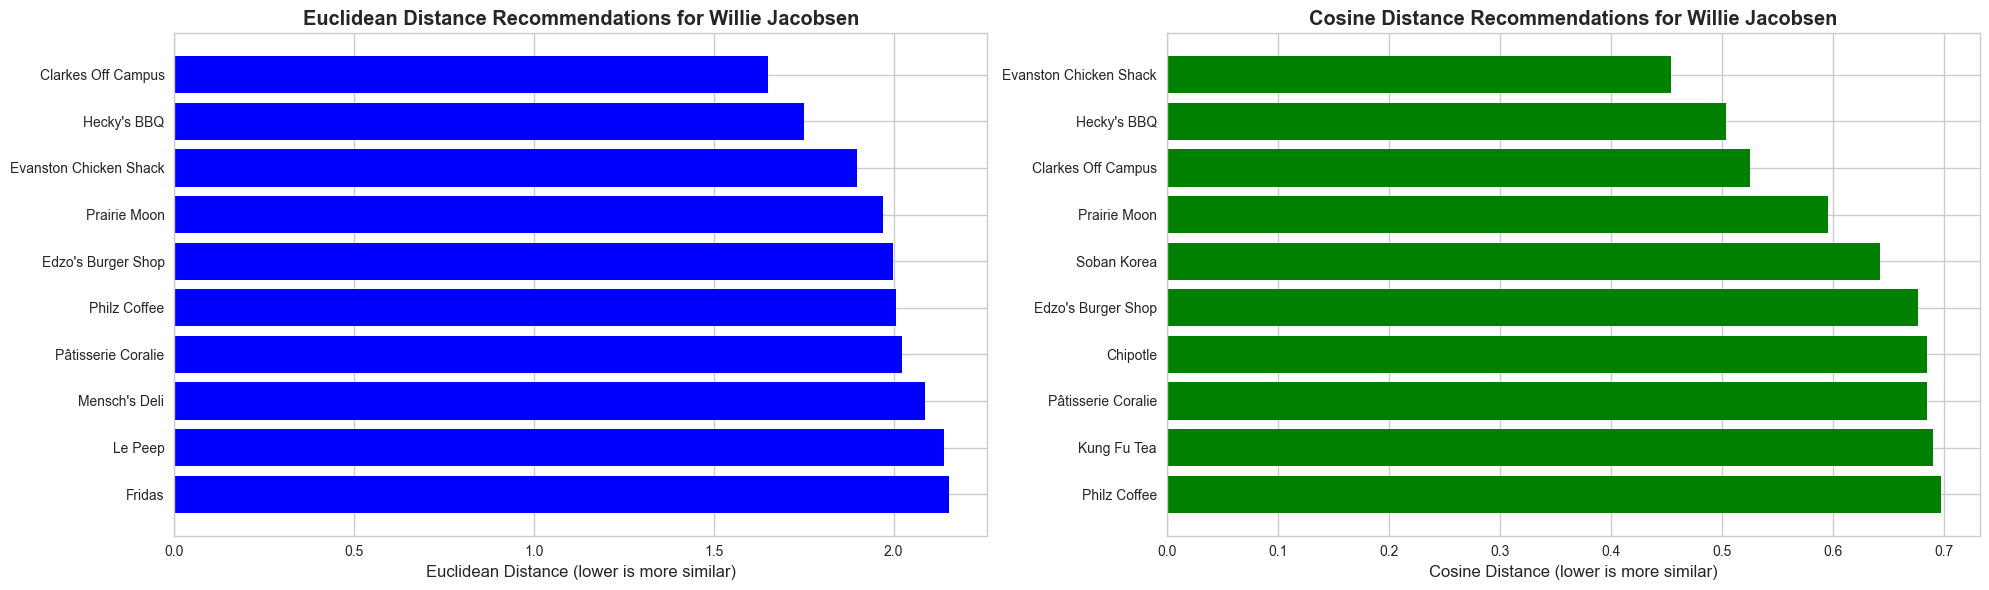


Evaluation of recommendation methods:
User: Willie Jacobsen
Favorite restaurant: Jimmy Johns (Cuisine: American)

Euclidean distance method:
  Top rated restaurant hit accuracy: 100.0%

Cosine distance method:
  Top rated restaurant hit accuracy: 50.0%

Multi-user evaluation (across 1086 users):
Average accuracy for Euclidean distance: 96.91%
Average accuracy for Cosine distance: 96.77%

Example Recommendation Results:
--------------------------------
User: Willie Jacobsen

Euclidean Distance Recommendations:
Restaurant Name                 Cuisine
----------------------------------------
Clarkes Off Campus             American       
Hecky's BBQ                    American       
Evanston Chicken Shack         American       
Prairie Moon                   American       
Edzo's Burger Shop             Burgers        
Philz Coffee                   Coffee         
Pâtisserie Coralie             Coffee         
Mensch's Deli                  Deli           
Le Peep                    

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# Encode restaurant features for content-based filtering
def encode_restaurant_features(df):
    """Encode restaurant features for content-based filtering."""
    # Create categorical features
    cuisine_encoded = pd.get_dummies(df['Cuisine'], prefix='Cuisine')
    
    # Create numeric features
    df_encoded = pd.DataFrame({
        'Open_After_8pm': df['Open After 8pm?'].map({'Yes': 1, 'No': 0}),
        'Average_Cost': pd.to_numeric(df['Average Cost'], errors='coerce'),
        'Latitude': pd.to_numeric(df['Latitude'], errors='coerce'),
        'Longitude': pd.to_numeric(df['Longitude'], errors='coerce'),
        'Restaurant Name': df['Restaurant Name']
    })
    
    # Normalize numeric features
    scaler = StandardScaler()
    numeric_features = ['Average_Cost', 'Latitude', 'Longitude']
    df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])
    
    # Combine all features
    return pd.concat([df_encoded, cuisine_encoded], axis=1)

# Generate TF-IDF embeddings for restaurant descriptions
print("Generating TF-IDF embeddings for restaurant descriptions...")
tfidf_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
description_embeddings = tfidf_vectorizer.fit_transform(restaurants['Brief Description']).toarray()
print(description_embeddings.shape)

encoded_restaurants = encode_restaurant_features(restaurants)

# Add TF-IDF embeddings to the encoded features
embedding_df = pd.DataFrame(
    {f'tfidf_embedding_{i}': description_embeddings[:, i] for i in range(description_embeddings.shape[1])},
    index=encoded_restaurants.index
)
encoded_restaurants = pd.concat([encoded_restaurants, embedding_df], axis=1)

# Get feature matrix (excluding restaurant name)
feature_matrix = encoded_restaurants.drop('Restaurant Name', axis=1).values.astype(float)

# Compute distance matrices
euclidean_dist_matrix = squareform(pdist(feature_matrix, 'euclidean'))
cosine_dist_matrix = squareform(pdist(feature_matrix, 'cosine'))

# Create dataframes for the distance matrices
restaurant_names = encoded_restaurants['Restaurant Name'].values
euclidean_df = pd.DataFrame(euclidean_dist_matrix, index=restaurant_names, columns=restaurant_names)
cosine_df = pd.DataFrame(cosine_dist_matrix, index=restaurant_names, columns=restaurant_names)

# Compare specific restaurant pairs
restaurant_pairs = [
    ('Peppercorns Kitchen', 'Epic Burger'),
    ('Peppercorns Kitchen', 'Lao Sze Chuan')
]

print("Comparing restaurant similarities:")
for r1, r2 in restaurant_pairs:
    print(f"\n{r1} vs {r2}:")
    print(f"  Euclidean distance: {euclidean_df.loc[r1, r2]:.4f}")
    print(f"  Cosine distance: {cosine_df.loc[r1, r2]:.4f}")
    print(f"  Cuisine types: {restaurants[restaurants['Restaurant Name'] == r1]['Cuisine'].values[0]} vs "
          f"{restaurants[restaurants['Restaurant Name'] == r2]['Cuisine'].values[0]}")



# 3.2

def recommend_restaurants(user_name, reviews_df, restaurants_df, euclidean_dist_df, cosine_dist_df, n=10):
    """Recommend restaurants for a user based on their favorite restaurant."""
    user_reviews = reviews_df[reviews_df['Reviewer Name'] == user_name]
    favorite_restaurant = user_reviews.loc[user_reviews['Rating'].idxmax()]['Restaurant Name']
    
    euclidean_recommendations = euclidean_dist_df[favorite_restaurant].sort_values()
    euclidean_recommendations = euclidean_recommendations[euclidean_recommendations.index != favorite_restaurant].head(n)
    
    cosine_recommendations = cosine_dist_df[favorite_restaurant].sort_values()
    cosine_recommendations = cosine_recommendations[cosine_recommendations.index != favorite_restaurant].head(n)
    
    euclidean_recs_info = restaurants_df[restaurants_df['Restaurant Name'].isin(euclidean_recommendations.index)]
    cosine_recs_info = restaurants_df[restaurants_df['Restaurant Name'].isin(cosine_recommendations.index)]
    
    return {
        "user": user_name,
        "favorite_restaurant": favorite_restaurant,
        "favorite_cuisine": restaurants_df[restaurants_df['Restaurant Name'] == favorite_restaurant]['Cuisine'].values[0],
        "euclidean_recommendations": {
            "restaurants": euclidean_recommendations.index.tolist(),
            "distances": euclidean_recommendations.values.tolist(),
            "info": euclidean_recs_info
        },
        "cosine_recommendations": {
            "restaurants": cosine_recommendations.index.tolist(),
            "distances": cosine_recommendations.values.tolist(),
            "info": cosine_recs_info
        }
    }

# Get recommendations for Willie Jacobsen
willie_recommendations = recommend_restaurants('Willie Jacobsen', reviews, restaurants, euclidean_df, cosine_df)

# Display Willie's favorite restaurant
print(f"\nWillie Jacobsen's favorite restaurant: {willie_recommendations['favorite_restaurant']} "
      f"(Cuisine: {willie_recommendations['favorite_cuisine']})")

# Create dataframes for recommendations
def create_recommendation_df(recommendations, restaurants_df, metric_type):
    return pd.DataFrame({
        'Restaurant': recommendations[f'{metric_type}_recommendations']['restaurants'],
        'Distance': recommendations[f'{metric_type}_recommendations']['distances'],
        'Cuisine': [restaurants_df[restaurants_df['Restaurant Name'] == r]['Cuisine'].values[0] 
                   for r in recommendations[f'{metric_type}_recommendations']['restaurants']]
    })

# Display top 10 recommendations
euclidean_recs_df = create_recommendation_df(willie_recommendations, restaurants, 'euclidean')
cosine_recs_df = create_recommendation_df(willie_recommendations, restaurants, 'cosine')

print("\nTop 10 recommendations based on Euclidean distance:")
print(euclidean_recs_df)

print("\nTop 10 recommendations based on Cosine distance:")
print(cosine_recs_df)

# Visualize recommendations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot Euclidean distance recommendations
ax1.barh(euclidean_recs_df['Restaurant'][::-1], euclidean_recs_df['Distance'][::-1], color='blue')
ax1.set_title(f"Euclidean Distance Recommendations for {willie_recommendations['user']}", fontweight='bold')
ax1.set_xlabel('Euclidean Distance (lower is more similar)')

# Plot Cosine distance recommendations
ax2.barh(cosine_recs_df['Restaurant'][::-1], cosine_recs_df['Distance'][::-1], color='green')
ax2.set_title(f"Cosine Distance Recommendations for {willie_recommendations['user']}", fontweight='bold')
ax2.set_xlabel('Cosine Distance (lower is more similar)')

plt.tight_layout()
plt.show()
# Evaluate recommendation quality
def evaluate_recommendation_quality(user_name, reviews_df, restaurants_df, euclidean_dist_df, cosine_dist_df):
    """Evaluate the quality of recommendations from different distance metrics."""
    # Get recommendations
    recommendations = recommend_restaurants(user_name, reviews_df, restaurants_df, euclidean_dist_df, cosine_dist_df, n=10)
    
    favorite_restaurant = recommendations['favorite_restaurant']
    favorite_cuisine = recommendations['favorite_cuisine']
    
    results = {"user": user_name, "favorite_restaurant": favorite_restaurant, "favorite_cuisine": favorite_cuisine}
    
    # Get the user's reviews
    user_reviews = reviews_df[reviews_df['Reviewer Name'] == user_name]
    
    # Get highly rated restaurants (rating >= 4)
    highly_rated = set(user_reviews[user_reviews['Rating'] >= 4]['Restaurant Name'].tolist())
    
    # Get poorly rated restaurants (rating < 4)
    poorly_rated = set(user_reviews[user_reviews['Rating'] < 4]['Restaurant Name'].tolist())
    for metric in ['euclidean', 'cosine']:
        recommended_restaurants = set(recommendations[f'{metric}_recommendations']['restaurants'])
        
  
        accuracy = 0
     
        if len(highly_rated) > 1:
            intersection_count = len(highly_rated.intersection(recommended_restaurants))
            hit_ratio = intersection_count / len(highly_rated)
            accuracy += 0.5 * hit_ratio
        else:
            # If user has no highly rated restaurants, give half credit for this part
            accuracy += 0.5
        
        if not poorly_rated.intersection(recommended_restaurants):
            accuracy += 0.5
        
        # Convert to percentage
        accuracy_percentage = accuracy * 100
        
        results[metric] = {
            "top_rated_hit_accuracy": accuracy_percentage
        }
    
    return results

# Evaluate recommendation quality for Willie Jacobsen
evaluation = evaluate_recommendation_quality('Willie Jacobsen', reviews, restaurants, euclidean_df, cosine_df)

# Display evaluation results
print("\nEvaluation of recommendation methods:")
print(f"User: {evaluation['user']}")
print(f"Favorite restaurant: {evaluation['favorite_restaurant']} (Cuisine: {evaluation['favorite_cuisine']})")

for metric in ['euclidean', 'cosine']:
    print(f"\n{metric.capitalize()} distance method:")
    print(f"  Top rated restaurant hit accuracy: {evaluation[metric]['top_rated_hit_accuracy']:.1f}%")

# Evaluate across multiple users
def evaluate_across_users(reviews_df, restaurants_df, euclidean_dist_df, cosine_dist_df, num_users=20):
    """Evaluate recommendation metrics across multiple users."""
    user_counts = reviews_df[reviews_df['Rating'] >= 0]['Reviewer Name'].value_counts()
    eligible_users = user_counts.index.tolist()
    
    # Select a sample of users (or all if less than num_users)
    sample_users = eligible_users[:min(num_users, len(eligible_users))]
    
    euclidean_accuracy = []
    cosine_accuracy = []
    
    for user in sample_users:
        try:
            eval_result = evaluate_recommendation_quality(user, reviews_df, restaurants_df, 
                                                         euclidean_dist_df, cosine_dist_df)
            if "error" not in eval_result:
                euclidean_accuracy.append(eval_result['euclidean']['top_rated_hit_accuracy'])
                cosine_accuracy.append(eval_result['cosine']['top_rated_hit_accuracy'])
        except Exception as e:
            print(f"Error evaluating user {user}: {e}")
            continue
    
    return {
        "euclidean_avg_accuracy": np.mean(euclidean_accuracy) if euclidean_accuracy else 0,
        "cosine_avg_accuracy": np.mean(cosine_accuracy) if cosine_accuracy else 0,
        "num_users_evaluated": len(euclidean_accuracy)
    }

# Run evaluation across multiple users
multi_user_eval = evaluate_across_users(reviews, restaurants, euclidean_df, cosine_df,num_users=reviews['Reviewer Name'].count())

# Visualize evaluation
metrics = ['Top Rated Hit %']
euclidean_values = [evaluation['euclidean']['top_rated_hit_accuracy']]
cosine_values = [evaluation['cosine']['top_rated_hit_accuracy']]

x = np.arange(len(metrics))
 
 

# Display multi-user evaluation results
print(f"\nMulti-user evaluation (across {multi_user_eval['num_users_evaluated']} users):")
print(f"Average accuracy for Euclidean distance: {multi_user_eval['euclidean_avg_accuracy']:.2f}%")
print(f"Average accuracy for Cosine distance: {multi_user_eval['cosine_avg_accuracy']:.2f}%")

 

# Add a grid for better readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Define a test user for example recommendations
test_users = ['Willie Jacobsen','Olya S','Paulette Cruz']  
for test_user in test_users:
    print("\nExample Recommendation Results:")
    print("--------------------------------")
    print(f"User: {test_user}")
    print("\nEuclidean Distance Recommendations:")
    print("Restaurant Name                 Cuisine")
    print("----------------------------------------")
    for i, rest in enumerate(euclidean_recs_df['Restaurant'][:10]):
        cuisine = restaurants[restaurants['Restaurant Name']==rest]['Cuisine'].values[0]
        print(f"{rest:<30} {cuisine:<15}")

    print(f"\nTop Rated Hit Accuracy: {evaluation['euclidean']['top_rated_hit_accuracy']:.2f}%")

    print("\nCosine Similarity Recommendations:")
    print("Restaurant Name                 Cuisine")
    print("----------------------------------------")
    for i, rest in enumerate(cosine_recs_df['Restaurant'][:10]):
        cuisine = restaurants[restaurants['Restaurant Name']==rest]['Cuisine'].values[0]
        print(f"{rest:<30} {cuisine:<15}")

    print(f"\nTop Rated Hit Accuracy: {evaluation['cosine']['top_rated_hit_accuracy']:.2f}%")

    # Show all restaurants rated by this user
    user_ratings = reviews[reviews['Reviewer Name'] == test_user]
    user_ratings_sorted = user_ratings.sort_values('Rating', ascending=False)

    print("\nAll Restaurants Rated by User:")
    print("Restaurant Name                 Cuisine        Actual Rating")
    print("-------------------------------------------------------------")
    for _, row in user_ratings_sorted.iterrows():
        rest_name = row['Restaurant Name']
        cuisine = restaurants[restaurants['Restaurant Name']==rest_name]['Cuisine'].values[0]
        print(f"{rest_name:<30} {cuisine:<15} {row['Rating']}")


 

## NLP

Restaurants with highest TF-IDF score for 'cozy':
- Taste of Nepal: 0.2890
- Dave's Italian Kitchen: 0.2869
- Prairie Moon: 0.2772

Restaurants with highest TF-IDF score for 'Chinese':
- Lao Sze Chuan: 0.4576
- Shangri-La Evanston: 0.3002
- Joy Yee Noodle: 0.2827

TF-IDF Distances between Restaurant Pairs:
Burger King and Edzo's Burger Shop: 0.5197
Burger King and Oceanique: 0.9997
Lao Sze Chuan and Kabul House: 0.7273


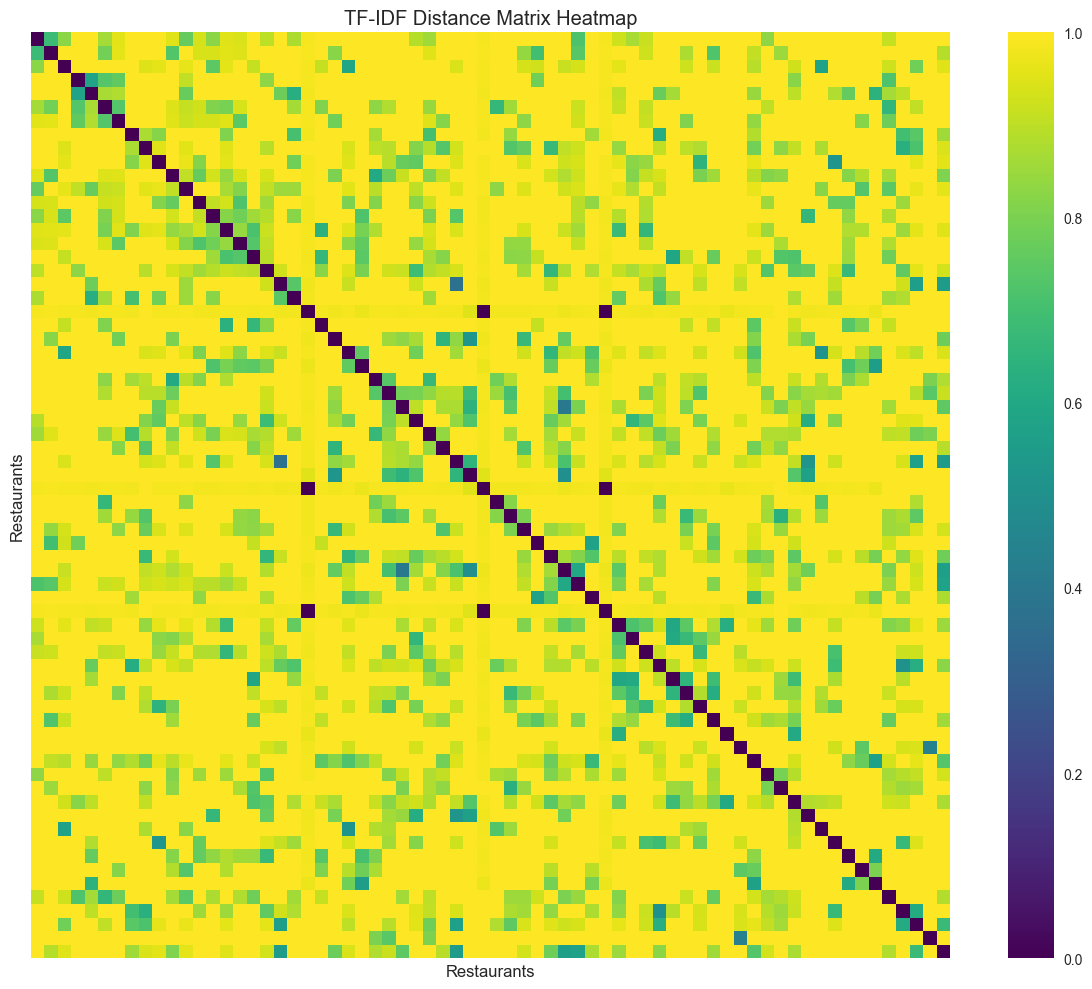


Most similar restaurants to Burger King:
            Restaurant        Cuisine  TF-IDF Distance
9   Edzo's Burger Shop        Burgers         0.519709
64            Dos Bros        Mexican         0.672826
46            Chipotle        Mexican         0.687138
45      Steak n' Shake        Burgers         0.708345
12        Cross Rhodes  Mediterranean         0.761770

Most similar restaurants to Edzo's Burger Shop:
            Restaurant   Cuisine  TF-IDF Distance
59         Burger King   Burgers         0.519709
49         Epic Burger   Burgers         0.647845
28  Clarkes Off Campus  American         0.755843
27     Barn Steakhouse  American         0.766653
19              Picnic     Salad         0.783153

Most similar restaurants to Oceanique:
                Restaurant      Cuisine  TF-IDF Distance
67           Mensch's Deli         Deli         0.577379
39                  Alcove     American         0.600365
0          Tapas Barcelona      Spanish         0.717301
1          

In [110]:
# Augment restaurant descriptions with cuisine type
restaurants['Augmented Description'] = restaurants['Brief Description'] + ' ' + restaurants['Cuisine']

from sklearn.feature_extraction.text import TfidfVectorizer
import re
from collections import Counter

def calculate_tfidf_for_word(word, descriptions):
    tfidf_vectorizer = TfidfVectorizer(lowercase=True, stop_words='english')
    tfidf_matrix = tfidf_vectorizer.fit_transform(descriptions)
    feature_names = tfidf_vectorizer.get_feature_names_out()
    if word.lower() in feature_names:
        word_index = list(feature_names).index(word.lower())
        word_tfidf_scores = tfidf_matrix[:, word_index].toarray().flatten()
        restaurant_tfidf_scores = dict(zip(restaurants['Restaurant Name'], word_tfidf_scores))
        # Sort by TF-IDF score in descending order
        sorted_scores = {k: v for k, v in sorted(restaurant_tfidf_scores.items(), key=lambda item: item[1], reverse=True) if v > 0}
        
        return sorted_scores
    else:
        return f"The word '{word}' does not appear in the vocabulary."

# Calculate TF-IDF scores for 'cozy' and 'Chinese'
cozy_tfidf = calculate_tfidf_for_word('cozy', restaurants['Augmented Description'])
chinese_tfidf = calculate_tfidf_for_word('chinese', restaurants['Augmented Description'])

# Display results
print("Restaurants with highest TF-IDF score for 'cozy':")
for restaurant, score in list(cozy_tfidf.items())[:3]:
    print(f"- {restaurant}: {score:.4f}")

print("\nRestaurants with highest TF-IDF score for 'Chinese':")
for restaurant, score in list(chinese_tfidf.items())[:3]:
    print(f"- {restaurant}: {score:.4f}")

# Function to get most common words from descriptions
def get_most_common_words(descriptions, n=100):
    # Combine all descriptions
    all_text = ' '.join(descriptions)
    
    # Convert to lowercase and split into words
    words = re.findall(r'\b\w+\b', all_text.lower())
    
    # Remove common English stop words
    stop_words = set(['a', 'an', 'the', 'and', 'or', 'but', 'is', 'are', 'in', 'on', 'at', 'to', 'for', 'with', 'by', 'of', 'from'])
    filtered_words = [word for word in words if word not in stop_words and word.isalpha() and len(word) > 2]
    word_counts = Counter(filtered_words)
    
    return [word for word, count in word_counts.most_common(n)]

# Get the 100 most common words
top_100_words = get_most_common_words(restaurants['Augmented Description'], 100)

# Create TF-IDF vectors for each restaurant based on the top 100 words
restaurant_tfidf_vectors = []

for idx, restaurant_desc in enumerate(restaurants['Augmented Description']):
    tfidf_vector = []
    
    # Convert description to lowercase and split into words
    restaurant_words = set(re.findall(r'\b\w+\b', restaurant_desc.lower()))
    
    # Calculate TF-IDF for each of the top 100 words
    for word in top_100_words:

        tf = 1 if word in restaurant_words else 0
        documents_with_word = sum(1 for desc in restaurants['Augmented Description'] 
                                if word in set(re.findall(r'\b\w+\b', desc.lower())))
        idf = np.log(len(restaurants) / (1 + documents_with_word))
        
        tfidf = tf * idf
        tfidf_vector.append(tfidf)
    
    restaurant_tfidf_vectors.append(tfidf_vector)

restaurant_tfidf_vectors = np.array(restaurant_tfidf_vectors)
from scipy.spatial.distance import pdist, squareform
tfidf_distances = squareform(pdist(restaurant_tfidf_vectors, 'cosine'))

burger_king_idx = restaurants[restaurants['Restaurant Name'] == 'Burger King'].index[0]
edzos_idx = restaurants[restaurants['Restaurant Name'] == "Edzo's Burger Shop"].index[0]
oceanique_idx = restaurants[restaurants['Restaurant Name'] == 'Oceanique'].index[0]
lao_sze_chuan_idx = restaurants[restaurants['Restaurant Name'] == 'Lao Sze Chuan'].index[0]
kabul_house_idx = restaurants[restaurants['Restaurant Name'] == 'Kabul House'].index[0]

# Calculate and display TF-IDF distances between specified restaurant pairs
print("\nTF-IDF Distances between Restaurant Pairs:")
print(f"Burger King and Edzo's Burger Shop: {tfidf_distances[burger_king_idx, edzos_idx]:.4f}")
print(f"Burger King and Oceanique: {tfidf_distances[burger_king_idx, oceanique_idx]:.4f}")
print(f"Lao Sze Chuan and Kabul House: {tfidf_distances[lao_sze_chuan_idx, kabul_house_idx]:.4f}")
# Visualize the TF-IDF distances as a heatmap
plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(tfidf_distances, cmap='viridis', xticklabels=False, yticklabels=False)
plt.title('TF-IDF Distance Matrix Heatmap')
plt.xlabel('Restaurants')
plt.ylabel('Restaurants')
# The colorbar is automatically created by sns.heatmap, no need to call plt.colorbar()
plt.tight_layout()
plt.show()

# Find the most similar restaurants based on TF-IDF
def get_most_similar_restaurants(restaurant_name, n=5):
    idx = restaurants[restaurants['Restaurant Name'] == restaurant_name].index[0]
    # Get distances from this restaurant to all others
    distances = tfidf_distances[idx]
    # Sort by distance (excluding itself)
    similar_indices = np.argsort(distances)[1:n+1]
    similar_restaurants = restaurants.iloc[similar_indices]
    similar_distances = distances[similar_indices]
    
    return pd.DataFrame({
        'Restaurant': similar_restaurants['Restaurant Name'],
        'Cuisine': similar_restaurants['Cuisine'],
        'TF-IDF Distance': similar_distances
    })

# Display most similar restaurants for a few examples
print("\nMost similar restaurants to Burger King:")
print(get_most_similar_restaurants('Burger King'))

print("\nMost similar restaurants to Edzo's Burger Shop:")
print(get_most_similar_restaurants("Edzo's Burger Shop"))

print("\nMost similar restaurants to Oceanique:")
print(get_most_similar_restaurants('Oceanique'))
